# PyDevice IOC calculation

Began updating for multi-system (2026.08.06)

In [2]:
import epics
import numpy as np
import matplotlib.pyplot as plt
import time

In [3]:
lens_stacks = 9
combos = 2**9
print(combos)

512


In [4]:
energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

In [5]:
flag_HE = True

slitH = epics.caget("100idPyCRL:testSSH1.VAL")
slitV = epics.caget("100idPyCRL:testSSV1.VAL")
epics.caput("100idPyCRL:CRL:thickerr_flag", flag_HE)

print(f'Horizontal slits size: {slitH} m\nVertical slit size: {slitV} m')

cannot connect to 100idPyCRL:CRL:thickerr_flag
Horizontal slits size: 500.0 m
Vertical slit size: 300.0 m


In [6]:
fSize_array = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)
for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(1)
    fSize_array[i-6,:]=epics.caget("100idPyCRL:MS:fSizes")

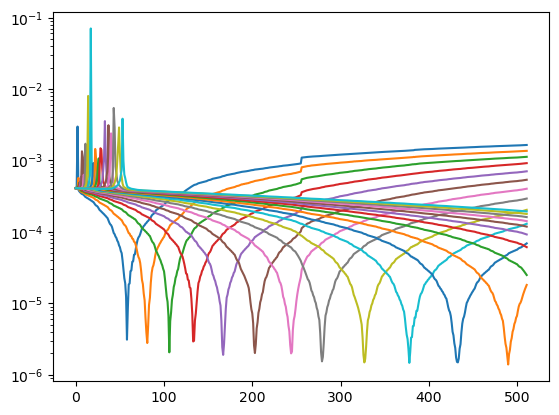

In [7]:
plt.plot(np.linspace(0,511,512), fSize_array.T)
plt.yscale('log')
plt.show()

Horizontal slits size: 500.0 m
Vertical slit size: 300.0 m


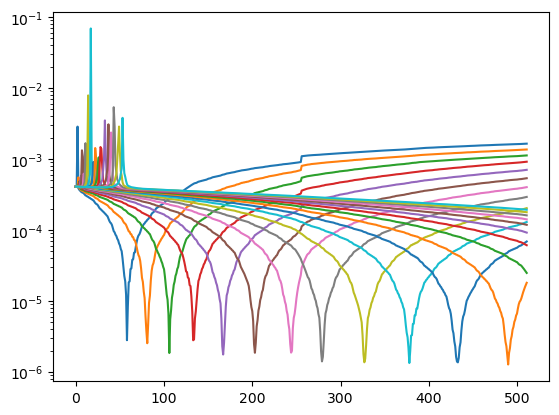

In [8]:
flag_HE = False

slitH = epics.caget("100idPyCRL:testSSH1.VAL")
slitV = epics.caget("100idPyCRL:testSSV1.VAL")
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

print(f'Horizontal slits size: {slitH} m\nVertical slit size: {slitV} m')

fSize_array = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)
for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(1)
    fSize_array[i-6,:]=epics.caget("100idPyCRL:MS:fSizes")

plt.plot(np.linspace(0,combos-1,combos), fSize_array.T)
plt.yscale('log')
plt.show()

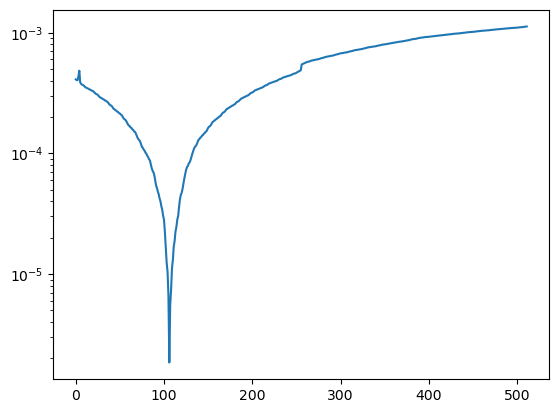

In [9]:
plt.plot(np.linspace(0,combos-1,combos), fSize_array[2,:])
plt.yscale('log')
plt.show()

# Xianbo Calculation

In [10]:
from scipy.optimize import root_scalar
import xraylib

In [11]:
# Lookup table where each entry is a tuple (column1, column2)
Lens_diameter_table = [
    (50, 450.0),
    (100, 632.0),
    (200, 894.0),
    (300, 1095.0),
    (500, 1414.0),
    (1000, 2000.0),
    (1500, 2450.0),
    ]

# Convert the lookup table to a dictionary for faster lookup
Lens_diameter_dict = {int(col1): col2 for col1, col2 in Lens_diameter_table}

In [12]:
def lookup_diameter(lens_radius):
    # Convert the input float to an integer
    input_int = int(round(lens_radius*1.0e6))
    return Lens_diameter_dict.get(input_int, (lens_radius*1.0e6)**0.5*63.222+ 0.73)/1.0e6

In [13]:
def index_to_binary_list(index, length):
    """
    Converts an index number to its binary representation as a list of digits,
    and pads the list with zeros in front to achieve the desired length.

    Parameters:
        index (int): The index number to be converted.
        length (int): The desired length of the binary list.

    Returns:
        list: A list of digits representing the binary representation of the index.
    """
    # Convert the index to a binary string and remove the '0b' prefix
    binary_str = bin(index)[2:]

    # Pad the binary string with zeros in front to achieve the desired length
    #padded_binary_str = binary_str.zfill(length)

    # Reverse the binary string
    reversed_binary_str = binary_str[::-1]

    # Convert the reversed binary string to a list of integers
    binary_list = [int(digit) for digit in reversed_binary_str]

    # Pad the list with zeros at the end to achieve the desired length
    while len(binary_list) < length:
        binary_list.append(0)

    return binary_list

In [14]:
def binary_list_to_index(binary_list, length):
    """
    Converts a list of binary digits in reverse order to its integer representation,
    padding the list with zeros at the end to have a fixed number of elements.

    Parameters:
        binary_list (list): A list of digits representing the binary number in reverse order.
        length (int): The fixed number of elements the list should have.

    Returns:
        int: The integer representation of the binary number.
    """
    # Pad the list with zeros at the end to achieve the desired length
    while len(binary_list) < length:
        binary_list.append(0)

    # Convert the binary list to an integer
    index = 0
    for i, digit in enumerate(binary_list):
        index += digit * 2**i

    return index

In [15]:
def materials_to_deltas(material_list, energy):
    """
    Convert a list of material names to a list of delta values at a given energy.
    Parameters:
        material_list (list): A list of material names.
        energy (float): The energy in keV.
    Returns:
        list: A list of delta values for the given materials at the given energy.
    """

    # The list to store delta values
    delta_list = []

    # Iterate through each material in the input list
    for material in material_list:
        # Compute the delta value for the current material at the given energy
        Z = xraylib.SymbolToAtomicNumber(material)
        density = xraylib.ElementDensity(Z)
        delta = 1.0-xraylib.Refractive_Index_Re(material, energy, density)

        # Add the delta value to the delta list
        delta_list.append(delta)

    return delta_list

In [16]:
def materials_to_linear_attenuation(material_list, energy):
    """
    Convert a list of material names to a list of linear attenuation coefficients at a given energy.
    Parameters:
        material_list (list): A list of material names.
        energy (float): The energy in keV.

    Returns:
        list: A list of linear attenuation coefficient values (in m^-1) for the given materials at the given energy.
    """
    # The list to store linear attenuation coefficient values
    mu_list = []

    # Iterate through each material in the input list
    for material in material_list:
        # Compute the delta value for the current material at the given energy
        Z = xraylib.SymbolToAtomicNumber(material)
        density = xraylib.ElementDensity(Z)

        # Compute the mass attenuation coefficient in cm^2/g
        #mass_attenuation = xraylib.CS_Photo(Z, energy)
        mass_attenuation = xraylib.CS_Total(Z, energy)

        # Convert mass attenuation coefficient to linear attenuation coefficient in m^-1
        mu = mass_attenuation * density * 100.0       

        # Add the linear attenuation coefficient value to the list
        mu_list.append(mu)
 
    return mu_list

In [17]:
def absorptionaperture(x, n1mud, sigma, n1mur):

    numerator = np.exp(-(x**2/(2*sigma**2))) * np.exp(-n1mur*(x**2) - n1mud)
    denominator = np.exp(-n1mud)

    return numerator / denominator - 0.5

In [18]:
def find_levels(array, levels, direction='forward'):
    """
    Find the first indices at which the array crosses specified levels and the corresponding crossed values.

    Parameters:
        array (numpy.ndarray): An array of numbers.
        levels (float or numpy.ndarray): A number or an array of levels to find crossings.
        direction (str, optional): The searching direction. Defaults to 'forward'.
                                   Can be either 'forward' or 'backward'.

    Returns:
        tuple: A tuple containing two arrays:
            - An array of first indices at which the array crosses the specified levels.
            - An array of first crossed values at the corresponding indices.
    """

    # Convert a single level to a numpy array
    if isinstance(levels, (int, float)):
        levels = np.array([levels])

    indices = []
    values = []

    # Compute the max and min of the array ignoring NaNs
    max_val = np.nanmax(array)
    min_val = np.nanmin(array)

    for level in levels:
        # If level is out of bounds
        if level > max_val or level < min_val:
            indices.append(-1)
            values.append(np.nan)
            continue

        crossings = []

        if direction == 'forward':
            for i in range(1, len(array)):
                if np.isnan(array[i - 1]) or np.isnan(array[i]):
                    continue
                if (array[i - 1] < level <= array[i]) or (array[i - 1] > level >= array[i]):
                    crossings.append(i - 1)
                    break
        elif direction == 'backward':
            for i in range(len(array) - 2, -1, -1):
                if np.isnan(array[i + 1]) or np.isnan(array[i]):
                    continue
                if (array[i + 1] < level <= array[i]) or (array[i + 1] > level >= array[i]):
                    crossings.append(i)
                    break
        else:
            raise ValueError("Invalid direction. It should be either 'forward' or 'backward'.")

        if len(crossings) > 0:
            idx = crossings[0]
            indices.append(idx)
            values.append(array[idx])
        else:
            # In case no crossing is found within the range
            indices.append(-1)
            values.append(np.nan)

    return np.array(indices), np.array(values)

In [19]:
def fSize_xs(energy, slit1_H = 500.0e-6, slit1_V = 300.0e-6, flag_HE = False, verbose = False, unsort = False):
    '''
    energy [eV]
    slit1_H [m]
    slit1_v [m]
    '''    
    
    energy_keV = energy/1000.0  # Energy in keV
    wl = 1239.84 / (energy * 10**9)
    d_StoL1 = 52.140              # Source-to-CRL1 distance, in m
    d_StoL2 = 62.340              # Source-to-CRL2 distance, in m
    d_Stof  = 55.0             # Source-to-focus distance, in m

#    slit1_H = 500.0e-6          # H slit size before CRL 1
#    slit1_V = 300.0e-6          # V slit size before CRL 1

    # CRL input block
    d_min   = 3.0e-5            # Minimum thickness at the apex in m
    stack_d = 50.0e-3           # Stack thickness in m
#    L1_n    = np.array([1,      1,      1,      1,      1,      1,      2,      4,      8,      16])                # CRL1 number of lenses in each stack
#    L1_R    = np.array([2.0e-3, 1.0e-3, 5.0e-4, 3.0e-4, 2.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4])            # CRL1 lens radius in each stack
#    L1_mater= np.array(["Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be"])              # CRL1 lens material in each stack
#    L1_loc  = np.array([4.5,    3.5,    2.5,    1.5,    0.5,    -0.5,   -1.5,   -2.5,   -3.5,   -4.5])*stack_d      # CRL1 lens stack location relative to center stack, positive means upstream
#    L1_HE   = np.array([1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.4e-6, 2.0e-6, 2.8e-6, 4.0e-6])            # CRL1 lens RMS thickness error

    L1_n    = np.array([1,      1,      1,      1,      1,      1,      2,      4,      8])                # CRL1 number of lenses in each stack
    L1_R    = np.array([2.0e-3, 1.0e-3, 5.0e-4, 3.0e-4, 2.0e-4, 1.0e-4, 1.0e-4, 1.0e-4, 1.0e-4])            # CRL1 lens radius in each stack
    L1_mater= np.array(["Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be",   "Be"])              # CRL1 lens material in each stack
    L1_loc  = np.array([0.118,    0.09,    0.062,    0.034,    0.006,    -0.022,   -0.05,   -0.078,   -0.118])      # CRL1 lens stack location relative to center stack, positive means upstream
    L1_HE   = np.array([1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.0e-6, 1.4e-6, 2.0e-6, 2.8e-6])            # CRL1 lens RMS thickness error
    
    
    # Source size input block
    L_und = 2.4                 # undulator length
    # Using Flat numbers
    sigmaH_e = 14.466e-6          # Sigma electron source size in H direction in m
    sigmaV_e = 3.075e-6           # Sigma electron source size in V direction in m
    sigmaHp_e = 2.749e-6          # Sigma electron divergence in H direction in rad
    sigmaVp_e = 1.293e-6          # Sigma electron divergence in V direction in rad

    sigmaH = (sigmaH_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
    sigmaV = (sigmaV_e**2 + wl*L_und/2/np.pi/np.pi)**0.5
    sigmaHp = (sigmaHp_e**2 + wl/L_und/2)**0.5
    sigmaVp = (sigmaVp_e**2 + wl/L_und/2)**0.5
    L1_D        = np.zeros(L1_R.size)                                   # CRL1 diameters for each stack
    for i in range(L1_R.size):
        L1_D[i] = lookup_diameter(L1_R[i])
    L1_delta    = materials_to_deltas(L1_mater, energy_keV)             # delta values for CRL1 stacks
    L1_mu       = materials_to_linear_attenuation(L1_mater, energy_keV) # mu values for CRL1 stacks
    L1_Feq      = L1_R/(2*L1_n*L1_delta) + L1_loc                       # CRL1 equivalent f in m for each stack
    L1_index_n  = 2**L1_Feq.size                                        # Total number of combinations for CRL1
    L1_invF_list= np.zeros(L1_index_n)                                  # List of equivalent 1/f in m^-1 for CRL1
    for i in range(L1_index_n):
        L1_invF_list[i] = np.sum(index_to_binary_list(i, L1_Feq.size)/L1_Feq)

    # comparing to IOC
    if verbose:
        print(L1_Feq)
        print(L1_invF_list)
    
    # Sort the L1_invF list (to avoid zigzagging)
    L1_invF_list_sort_indices = np.argsort(L1_invF_list)
    L1_invF_list_sorted       = L1_invF_list[L1_invF_list_sort_indices]
    q1_list  = 1/(L1_invF_list_sorted - 1/d_StoL1)      # focal position of CRL1 for all configurations (sorted)
    dq1_list = q1_list - (d_Stof - d_StoL1)

#    if verbose:
#        print(f'L1_invF_list_sort_indices {L1_invF_list_sort_indices}')
#        print(f'L1_invF_list_sorted {L1_invF_list_sorted}')
#        print(f'q1_list {q1_list}')
#        print(f'dq1_list {dq1_list}')
    
    # Start generating focal size list as a function of CRL1 setting
    sigma1H         = (sigmaH**2 + (sigmaHp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    sigma1V         = (sigmaV**2 + (sigmaVp*d_StoL1)**2)**0.5   # sigma beam size before CRL1
    L1_n1mud_list   = np.zeros(L1_index_n)                      # List of n1*mu*d_min for all possible CRL1 configurations
    L1_n1muR_list   = np.zeros(L1_index_n)                      # List of n1*mu/R for all possible CRL1 configurations
    aperL1H_list    = np.zeros(L1_index_n)                      # absorption H aperture of CRL1 for all configurations
    aperL1V_list    = np.zeros(L1_index_n)                      # absorption V aperture of CRL1 for all configurations
    diameter1_list  = np.zeros(L1_index_n)                      # CRL1 diameter for all possible configurations
    FWHM1H_list     = np.zeros(L1_index_n)                      # H focal size at the focus of CRL1
    FWHM1V_list     = np.zeros(L1_index_n)                      # V focal size at the focus of CRL1
    Strehl_list     = np.zeros(L1_index_n)                      # Strehl ratio based on lens thickness error

    for i in range(L1_index_n):
        # absorption aperture is a function of CRL absorption/physical aperture, incident beam size, and physical slits
        L1_n1mud_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n*d_min))
        L1_n1muR_list[i] = np.sum(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_mu*L1_n/L1_R))
        solution = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1H, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1H], method='bisect')
        aperL1H_list[i] = solution.root*2.0
        solution = root_scalar(absorptionaperture, args=(L1_n1mud_list[i], sigma1V, L1_n1muR_list[i]), bracket=[0.0, 2*sigma1V], method='bisect')
        aperL1V_list[i] = solution.root*2.0
        mask = (np.array(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)) == 1)

        if np.all(mask == False):
            diameter1_list[i] = np.inf
        else:
            diameter1_list[i] = np.min(L1_D[mask])
        aperL1H_list[i] = min(aperL1H_list[i], diameter1_list[i], slit1_H)
        aperL1V_list[i] = min(aperL1V_list[i], diameter1_list[i], slit1_V)

        phase_error_tmp = np.linalg.norm(index_to_binary_list(L1_invF_list_sort_indices[i], L1_Feq.size)*np.array(L1_HE*L1_delta)*2*np.pi/wl)
        Strehl_list[i] = np.exp(-phase_error_tmp**2)

#    if verbose:
#        print(f'L1_n1mud_list {L1_n1mud_list}')
#        print(f'L1_n1muR_list {L1_n1muR_list}' )
#       print(f'aperL1H_list {aperL1H_list}')
#        print(f'aperL1V_list {aperL1V_list}')
#        print(f'diameter1_list {diameter1_list}')
#        print(f'wl {wl}')
#        print(f'd_StoL1 {d_StoL1}')
#        print(f'sigmaH {sigmaH}')
#        print(f'sigmaV {sigmaV}')

    
    # FWHMbeam size at CRL1 focus
    FWHM1H_list  = ((0.88*wl*q1_list/aperL1H_list)**2 + (2.355*sigmaH*q1_list/d_StoL1)**2)**0.5
    FWHM1V_list  = ((0.88*wl*q1_list/aperL1V_list)**2 + (2.355*sigmaV*q1_list/d_StoL1)**2)**0.5
    if flag_HE:
        FWHM1H_list *= (Strehl_list)**(-0.5)
        FWHM1V_list *= (Strehl_list)**(-0.5)
#    FWHM_list   = (FWHM1H_list*FWHM1V_list)**0.5

    FWHM1H_atsample_list = (FWHM1H_list**2 + (aperL1H_list*dq1_list/q1_list)**2)**0.5
    FWHM1V_atsample_list = (FWHM1V_list**2 + (aperL1V_list*dq1_list/q1_list)**2)**0.5
    if unsort:
        # Unsorting to match original indices which correspond to lens configurations
        FWHM_atsample_list = np.empty(FWHM1V_atsample_list.shape)
        FWHM_atsample_list[L1_invF_list_sort_indices]   = (FWHM1H_atsample_list*FWHM1V_atsample_list)**0.5
    else:
        # Keeping in order of focal distance
        FWHM_atsample_list   = (FWHM1H_atsample_list*FWHM1V_atsample_list)**0.5

#   if verbose:
#       print(f'FWHM1H_list {FWHM1H_list}')
#       print(f'FWHM1V_list {FWHM1V_list}' )


    return FWHM_atsample_list, L1_invF_list_sorted, L1_invF_list_sort_indices
   


In [20]:
def find_config_xs(fSize, energy, slit1_H = 500.0e-6, slit1_V = 300.0e-6, flag_HE = False, verbose = False, unsort = False):
    FWHM_atsample_list, L1_invF_list_sorted, L1_invF_list_sort_indices = fSize_xs(energy, slit1_H = slit1_H, slit1_V = slit1_V, flag_HE = flag_HE, verbose = verbose, unsort = unsort)

    indices, values = find_levels(FWHM_atsample_list, fSize, direction='forward')
    index2 = indices[0]
    
    if index2 == -1:
        print(f"Cannot achieve the bame size {fSize*1.0e6:.2f} μm at sample")
        return -1, -1
    else:
        return FWHM_atsample_list[index2], L1_invF_list_sort_indices[index2] 



In [21]:
fSize_array_xs = np.empty([len(energy_list),combos])
for i in energies:
    fSize_array_xs[i-6,:], _, _=fSize_xs(i*1000.0, slit1_H = slitH, slit1_V = slitV, flag_HE = True)

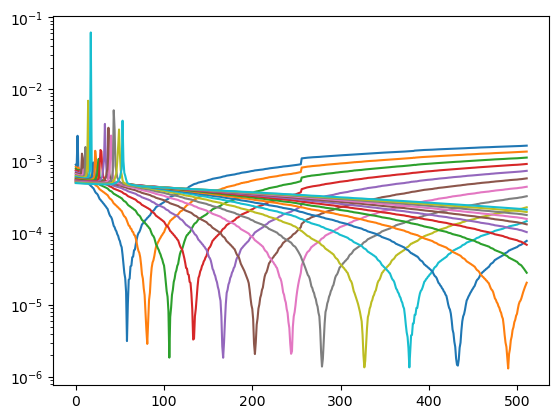

In [22]:
plt.plot(np.linspace(0,combos-1,combos), fSize_array_xs.T)
plt.yscale('log')
plt.show()

# Comparison

## 100 um x 100 um

In [23]:
slitH = 100
slitV = 100
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

fSize_array_A = np.empty([len(energy_list),combos])
fSize_array_xs_A = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)
for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(2)
    fSize_array_A[i-6,:]=epics.caget("100idPyCRL:MS:fSizes")
    fSize_array_xs_A[i-6,:], _, _=fSize_xs(i*1000.0, slit1_H = slitH/1e6, slit1_V = slitV/1e6, flag_HE = flag_HE, unsort = False)
ratio_A = fSize_array_A/fSize_array_xs_A

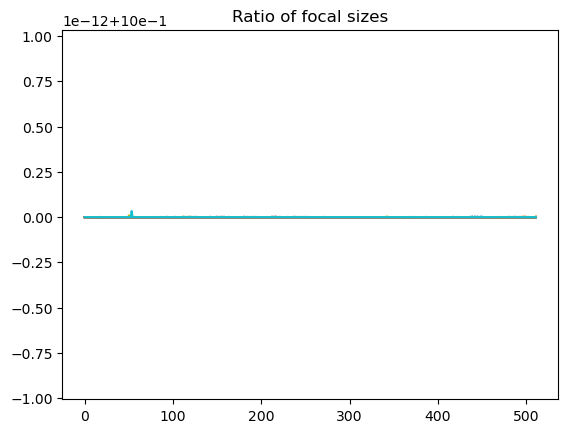

In [24]:
plt.plot(np.linspace(0,combos-1,combos), ratio_A.T)
plt.title('Ratio of focal sizes')
plt.show()

In [25]:
print(fSize_array_A[2,105:115])
print(fSize_array_xs_A[2,105:115])

[5.03065519e-06 4.67497888e-06 4.90902173e-06 4.86014246e-06
 5.38317843e-06 5.66365562e-06 6.36360863e-06 6.65037995e-06
 7.46168572e-06 7.87149147e-06]
[5.03065519e-06 4.67497888e-06 4.90902173e-06 4.86014246e-06
 5.38317843e-06 5.66365562e-06 6.36360863e-06 6.65037995e-06
 7.46168572e-06 7.87149147e-06]


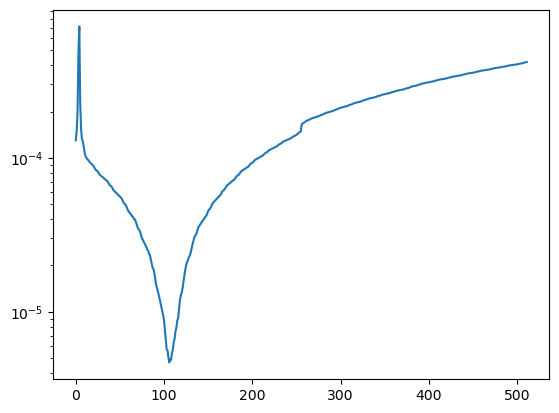

In [26]:
plt.plot(np.linspace(0,combos-1,combos), fSize_array_A[2,:])
#plt.plot(np.linspace(0,combos-1,combos), fSize_array_xs_A[2,:])
plt.yscale('log')
plt.show()

In [27]:
energies

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25])

In [28]:
# 6 keV -- low bit configurations
print(fSize_array_A[0,0:9])
print(fSize_array_xs_A[0,0:9])

[1.44413104e-04 2.27541310e-04 7.77699208e-03 2.43324150e-04
 1.41921506e-04 1.17481006e-04 1.04689917e-04 9.83260998e-05
 9.78044041e-05]
[1.44413104e-04 2.27541310e-04 7.77699208e-03 2.43324150e-04
 1.41921506e-04 1.17481006e-04 1.04689917e-04 9.83260998e-05
 9.78044041e-05]


In [29]:
# 6 keV -- high bit configurations
print(fSize_array_A[0,500:511])
print(fSize_array_xs_A[0,500:511])

[0.00085623 0.00085894 0.00086164 0.00086345 0.00086435 0.00086615
 0.00086886 0.00087157 0.00087426 0.00087697 0.00087968]
[0.00085623 0.00085894 0.00086164 0.00086345 0.00086435 0.00086615
 0.00086886 0.00087157 0.00087426 0.00087697 0.00087968]


In [30]:
# 25 keV
print(fSize_array_A[19,0:9])
print(fSize_array_xs_A[19,0:9])

[0.00011078 0.00011096 0.00011115 0.00011139 0.00011161 0.00011193
 0.00011226 0.00011248 0.00011269]
[0.00011078 0.00011096 0.00011115 0.00011139 0.00011161 0.00011193
 0.00011226 0.00011248 0.00011269]


In [31]:
# 25 keV -- high bit configurations
print(fSize_array_A[19,500:511])
print(fSize_array_xs_A[19,500:511])

[5.64114644e-05 5.62556909e-05 5.60991037e-05 5.59938931e-05
 5.59433413e-05 5.58381338e-05 5.56815700e-05 5.55258216e-05
 5.53684807e-05 5.52127424e-05 5.50562091e-05]
[5.64114644e-05 5.62556909e-05 5.60991037e-05 5.59938931e-05
 5.59433413e-05 5.58381338e-05 5.56815700e-05 5.55258216e-05
 5.53684807e-05 5.52127424e-05 5.50562091e-05]


## 500 um x 300 um

In [32]:
slitH = 500
slitV = 300
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

fSize_array_B = np.empty([len(energy_list),combos])
fSize_array_xs_B = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)

for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(1)
    fSize_array_B[int(i-6),:]=epics.caget("100idPyCRL:MS:fSizes")
    fSize_array_xs_B[i-6,:], _, _=fSize_xs(i*1000.0, slit1_H = slitH/1e6, slit1_V = slitV/1e6, flag_HE = flag_HE, unsort = False)
ratio_B = fSize_array_B/fSize_array_xs_B

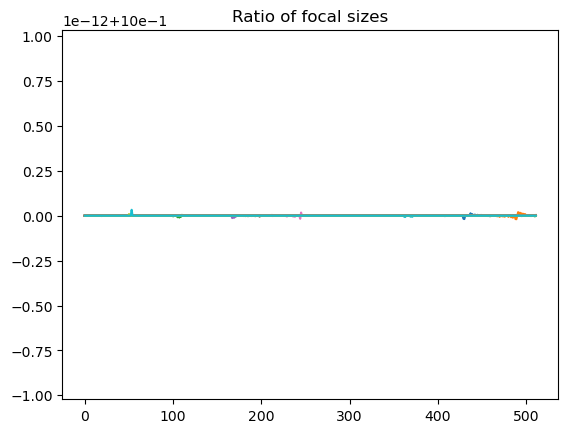

In [33]:
plt.plot(np.linspace(0,combos-1,combos), ratio_B.T)
plt.title('Ratio of focal sizes')

plt.show()

In [34]:
# 6 keV -- low bit configurations
print(fSize_array_B[0,0:9])
print(fSize_array_xs_B[0,0:9])

[0.00041036 0.00040589 0.00298404 0.00038704 0.00036897 0.0003573
 0.00034634 0.00033915 0.00033566]
[0.00041036 0.00040589 0.00298404 0.00038704 0.00036897 0.0003573
 0.00034634 0.00033915 0.00033566]


In [35]:
# 6 keV -- high bit configurations
print(fSize_array_B[0,500:511])
print(fSize_array_xs_B[0,500:511])

[0.00162263 0.0016253  0.00162797 0.00162974 0.00163064 0.00163241
 0.00163506 0.00163772 0.00164035 0.00164299 0.00164563]
[0.00162263 0.0016253  0.00162797 0.00162974 0.00163064 0.00163241
 0.00163506 0.00163772 0.00164035 0.00164299 0.00164563]


In [36]:
# 25 keV
print(fSize_array_B[19,0:9])
print(fSize_array_xs_B[19,0:9])

[0.00040913 0.00040857 0.00040801 0.00040745 0.00040689 0.00040634
 0.0004058  0.00040543 0.00040526]
[0.00040913 0.00040857 0.00040801 0.00040745 0.00040689 0.00040634
 0.0004058  0.00040543 0.00040526]


In [37]:
# 25 keV -- high bit configurations
print(fSize_array_B[19,500:511])
print(fSize_array_xs_B[19,500:511])

[0.00019914 0.00019854 0.00019793 0.00019752 0.00019732 0.00019692
 0.00019631 0.0001957  0.0001951  0.00019449 0.00019389]
[0.00019914 0.00019854 0.00019793 0.00019752 0.00019732 0.00019692
 0.00019631 0.0001957  0.0001951  0.00019449 0.00019389]


## 1 mm x 0.5 mm

In [38]:
slitH = 1000
slitV = 500
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

fSize_array_C = np.empty([len(energy_list),combos])
fSize_array_xs_C = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)
for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(1)
    fSize_array_C[i-6,:]=epics.caget("100idPyCRL:MS:fSizes")
    fSize_array_xs_C[i-6,:], _, _=fSize_xs(i*1000.0, slit1_H = slitH/1e6, slit1_V = slitV/1e6, flag_HE = flag_HE, unsort = False)
ratio_C = fSize_array_C/fSize_array_xs_C

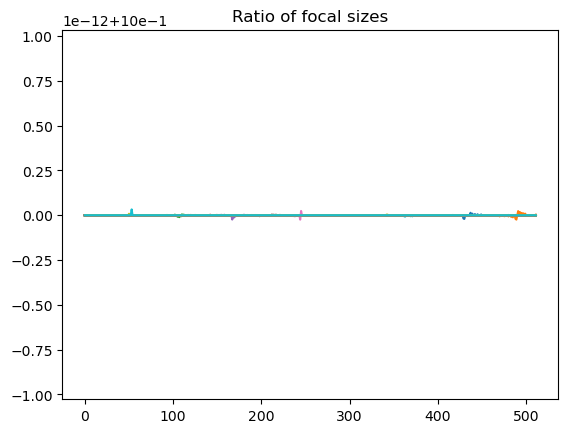

In [39]:
plt.plot(np.linspace(0,combos-1,combos), ratio_C.T)
plt.title('Ratio of focal sizes')
plt.show()

In [40]:
# 6 keV -- low bit configurations
print(fSize_array_C[0,0:9])
print(fSize_array_xs_C[0,0:9])

[0.00069803 0.00067178 0.00243758 0.0006196  0.0005919  0.00056744
 0.00054408 0.00052897 0.00052156]
[0.00069803 0.00067178 0.00243758 0.0006196  0.0005919  0.00056744
 0.00054408 0.00052897 0.00052156]


In [41]:
# 6 keV -- high bit configurations
print(fSize_array_C[0,500:511])
print(fSize_array_xs_C[0,500:511])

[0.00162263 0.0016253  0.00162797 0.00162974 0.00163064 0.00163241
 0.00163506 0.00163772 0.00164035 0.00164299 0.00164563]
[0.00162263 0.0016253  0.00162797 0.00162974 0.00163064 0.00163241
 0.00163506 0.00163772 0.00164035 0.00164299 0.00164563]


In [42]:
# 25 keV
print(fSize_array_C[19,0:9])
print(fSize_array_xs_C[19,0:9])

[0.00049697 0.00049591 0.00049485 0.00049381 0.00049276 0.00049173
 0.0004907  0.00049001 0.00048968]
[0.00049697 0.00049591 0.00049485 0.00049381 0.00049276 0.00049173
 0.0004907  0.00049001 0.00048968]


In [43]:
# 25 keV -- high bit configurations
print(fSize_array_C[19,500:511])
print(fSize_array_xs_C[19,500:511])

[0.00021928 0.00021857 0.00021785 0.00021737 0.00021714 0.00021666
 0.00021595 0.00021523 0.00021452 0.00021381 0.0002131 ]
[0.00021928 0.00021857 0.00021785 0.00021737 0.00021714 0.00021666
 0.00021595 0.00021523 0.00021452 0.00021381 0.0002131 ]


# Focal power comparison
Focal power ~ 1/focal distance

In [51]:
slitH = 500
slitV = 300
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

invF_array_B = np.empty([len(energy_list),combos])
invF_array_xs_B = np.empty([len(energy_list),combos])
epics.caput("100idPyCRL:MS:EnergySelect",1)

for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(1)
    invF_array_B[int(i-6),:]=epics.caget("100idPyCRL:MS:B:invF")
    _, invF_array_xs_B[i-6,:], _=fSize_xs(i*1000.0, slit1_H = slitH/1e6, slit1_V = slitV/1e6, flag_HE = flag_HE, unsort = False)
invF_ratio_B = invF_array_B/invF_array_xs_B

/tmp/ipykernel_8648/1046075701.py:21: RuntimeWarning: invalid value encountered in divide
  invF_ratio_B = invF_array_B/invF_array_xs_B


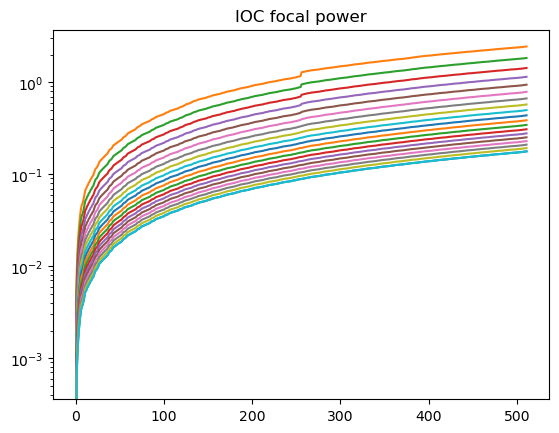

In [52]:
plt.plot(np.linspace(0,combos-1,combos), invF_array_B.T)
plt.title('IOC focal power')
plt.yscale('log')
plt.show()

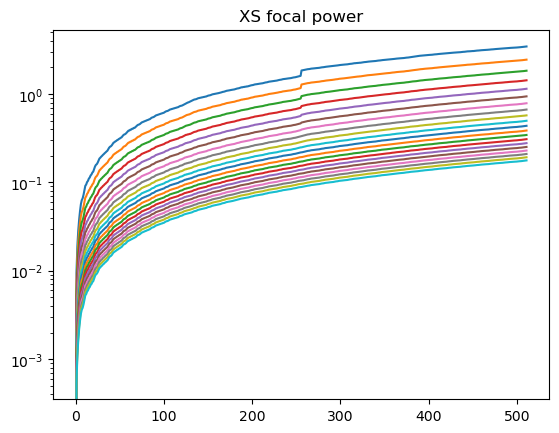

In [53]:
plt.plot(np.linspace(0,combos-1,combos), invF_array_xs_B.T)
plt.title('XS focal power')
plt.yscale('log')
plt.show()

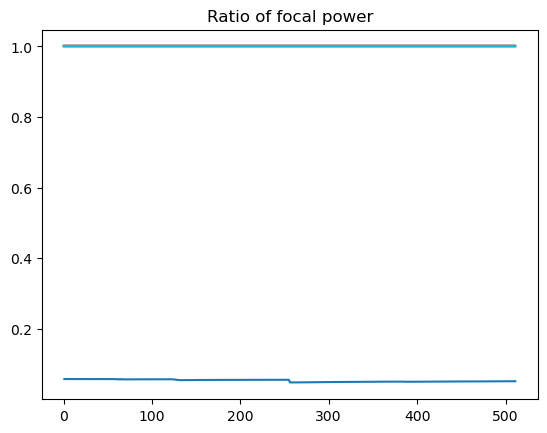

In [54]:
plt.plot(np.linspace(0,combos-1,combos), invF_ratio_B.T)
plt.title('Ratio of focal power')
plt.show()

In [55]:
print(np.min(invF_array_B))

0.0


# fSize/config Comparison
Cycles through range of possible focal sizes and seeing if IOC and XS code return same configurations

In [56]:
slitH = 500
slitV = 300
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

fSize = 1e-4

for i in energies:
    print(find_config_xs(fSize, i*1000.0, slit1_H = slitH/1e6, slit1_V = slitV/1e6, flag_HE = flag_HE, unsort = False))

(0.00010691131255551197, 42)
(0.00010241261276205469, 59)
(0.00010122221793815053, 77)
(0.00010383411864970728, 101)
(0.00010292233174113517, 124)
(0.00010151643982732008, 151)
(0.00010133258435870732, 182)
(0.00010131377929498152, 214)
(0.0001010123465980741, 249)
(0.00010091719796915277, 279)
(0.00010050444586724972, 322)
(0.00010115671770971751, 361)
(0.0001007910775848799, 405)
(0.00010054109430911028, 452)
(0.00010068739743810132, 500)
Cannot achieve the bame size 100.00 μm at sample
(-1, -1)
Cannot achieve the bame size 100.00 μm at sample
(-1, -1)
Cannot achieve the bame size 100.00 μm at sample
(-1, -1)
Cannot achieve the bame size 100.00 μm at sample
(-1, -1)
Cannot achieve the bame size 100.00 μm at sample
(-1, -1)


In [57]:
slitH = 500
slitV = 300
flag_HE = True

epics.caput("100idPyCRL:testSSH1.VAL", slitH)
epics.caput("100idPyCRL:testSSV1.VAL", slitV)
epics.caput("100idPyCRL:MS:thickerr_flag", flag_HE)

energy_list = [i for i in range(6,26)]
energies = np.asarray(energy_list)

fSize = 1e-4

for i in energies:
    epics.caput("100idPyCRL:MS:EnergyLocal",float(i))
    time.sleep(0.5)
    epics.caput("100idPyCRL:MS:previewFocalSize.VAL",float(fSize))
    time.sleep(0.5)
    fSize_actual = epics.caget("100idPyCRL:MS:previewFocalSize_actual")
    configIndex = epics.caget("100idPyCRL:MS:B:lens_preview")
    print(fSize_actual, configIndex)

0.00010691131255551197 42
0.00010241261276205469 59
0.00010122221793815053 77
0.00010383411864970728 101
0.00010292233174113517 124
0.00010151643982732008 151
0.00010133258435870732 182
0.00010131377929498152 214
0.0001010123465980741 249
0.00010091719796915277 279
0.00010050444586724972 322
0.00010115671770971751 361
0.0001007910775848799 405
0.00010054109430911028 452
0.00010068739743810132 500
0.00011846767477266075 511
0.00014127271906455636 511
0.0001610299650376927 511
0.00017823310748386393 511
0.00019328345512069532 511
